# Setup
1. In colab: Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
2. Install TerraTorch

In [ ]:
!pip install terratorch==0.99.8 gdown tensorboard segmentation-models-pytorch==0.3.4
# Note: After running this, you MUST restart the session (Runtime -> Restart session) for changes to take effect.

In [ ]:
import os
import sys
import torch
import gdown
# Explicitly check version to debug the ModuleNotFoundError
try:
    import segmentation_models_pytorch as smp
    print(f'SMP version: {smp.__version__}')
except ImportError:
    print('SMP not installed')

import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

SMP version: 0.3.4


3. Download the dataset from Google Drive

In [ ]:
if not os.path.isfile('hls_burn_scars.tar.gz'):
    gdown.download("https://drive.google.com/uc?id=1yFDNlGqGPxkc9lh9l1O70TuejXAQYYtC")
    !tar -xzvf hls_burn_scars.tar.gz

## HLS Burn Scars Dataset

Lets start with analyzing the dataset

In [ ]:
dataset_path = Path('hls_burn_scars')
!ls "hls_burn_scars/"

data  splits


In [ ]:
datamodule = terratorch.datamodules.GenericNonGeoSegmentationDataModule(
    batch_size=8,
    num_workers=2,
    num_classes=2,

    train_data_root=dataset_path / 'data/',
    train_label_data_root=dataset_path / 'data/',
    val_data_root=dataset_path / 'data/',
    val_label_data_root=dataset_path / 'data/',
    test_data_root=dataset_path / 'data/',
    test_label_data_root=dataset_path / 'data/',

    train_split=dataset_path / 'splits/train.txt',
    val_split=dataset_path / 'splits/val.txt',
    test_split=dataset_path / 'splits/test.txt',

    img_grep='*_merged.tif',
    label_grep='*.mask.tif',

    train_transform=[
        albumentations.D4(),
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,
    test_transform=None,

    means=[
        0.0333497067415863,
        0.0570118552053618,
        0.0588974813200132,
        0.2323245113436119,
        0.1972854853760658,
        0.1194491422518656,
    ],
    stds=[
        0.0226913556882377,
        0.0268075602230702,
        0.0400410984436278,
        0.0779173242367269,
        0.0870873883814014,
        0.0724197947743781,
    ],
)

datamodule.setup("fit")
train_dataset = datamodule.train_dataset
val_dataset = datamodule.val_dataset

In [ ]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

120

In [ ]:
sample = test_dataset[0]

print("Keys:", sample.keys())

for key, val in sample.items():
    if hasattr(val, "shape"):
        print(f"{key}: shape={val.shape}, type={type(val)}")
    else:
        print(f"{key}: {val}, type={type(val)}")

Keys: dict_keys(['image', 'mask', 'filename'])
image: shape=torch.Size([6, 512, 512]), type=<class 'torch.Tensor'>
mask: shape=torch.Size([512, 512]), type=<class 'torch.Tensor'>
filename: hls_burn_scars/data/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merged.tif, type=<class 'str'>


# Random Forest Baseline

In [ ]:
datamodule.setup("fit")
train_dataset = datamodule.train_dataset
val_dataset = datamodule.val_dataset

datamodule.setup("test")
test_dataset = datamodule.test_dataset

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 524
Val: 160
Test: 120


In [ ]:
import numpy as np
import torch
from tqdm import tqdm

def item_to_pixels(item, max_pixels=None, rng=None):
    image = item["image"]   # shape: [6, 512, 512]
    mask = item["mask"]     # shape: [512, 512]

    if torch.is_tensor(image):
        image = image.detach().cpu().numpy()
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    # [6, H, W] -> [H, W, 6] -> [H*W, 6]
    X = np.moveaxis(image, 0, -1).reshape(-1, image.shape[0])
    y = mask.reshape(-1).astype(np.int64)

    valid = np.isin(y, [0, 1])
    X = X[valid]
    y = y[valid]

    if max_pixels is not None and len(y) > max_pixels:
        idx = rng.choice(len(y), size=max_pixels, replace=False)
        X = X[idx]
        y = y[idx]

    return X, y


def build_pixel_table(dataset, pixels_per_image=3000, max_images=None):
    rng = np.random.default_rng(42)

    Xs = []
    ys = []

    n = len(dataset) if max_images is None else min(len(dataset), max_images)

    for i in tqdm(range(n)):
        item = dataset[i]
        X, y = item_to_pixels(item, max_pixels=pixels_per_image, rng=rng)
        Xs.append(X)
        ys.append(y)

    return np.vstack(Xs), np.concatenate(ys)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train, y_train = build_pixel_table(
    train_dataset,
    pixels_per_image=1000
)

rf = RandomForestClassifier(
    n_estimators=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Class counts:", np.bincount(y_train))

100%|██████████| 524/524 [00:35<00:00, 14.78it/s]


X_train: (524000, 6)
y_train: (524000,)
Class counts: [467062  56938]


In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, jaccard_score

def evaluate_segmentation(y_true, y_pred, num_classes=2):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    accuracy = accuracy_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    per_class_iou = jaccard_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average=None,
        zero_division=0
    )

    mean_iou = jaccard_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "mse": mse,
        "mean_iou": mean_iou,
        "per_class_iou": per_class_iou
    }


X_test, y_test = build_pixel_table(
    test_dataset,
    pixels_per_image=3000
)

rf_pred = rf.predict(X_test)

rf_results = evaluate_segmentation(y_test, rf_pred, num_classes=2)
rf_results

100%|██████████| 120/120 [00:09<00:00, 12.19it/s]


{'accuracy': 0.9506027777777778,
 'mse': 0.049397222222222224,
 'mean_iou': 0.7569098984669294,
 'per_class_iou': array([0.94719212, 0.56662767])}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Prithvi Checkpoint Evaluation

In [ ]:
pl.seed_everything(0)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="output/burnscars/checkpoints/",
    mode="max",
    monitor="val/Multiclass_Jaccard_Index", # Variable to monitor
    filename="best-{epoch:02d}",
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision='16-mixed',  # Speed up training
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=5, # For demos
    log_every_n_steps=1,
    enable_checkpointing=True,
    callbacks=[checkpoint_callback, pl.callbacks.RichProgressBar()],
    default_root_dir="output/burnscars",
)

# Model
model = terratorch.tasks.SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        # Backbone
        "backbone": "prithvi_eo_v2_300_tl", # Model can be either prithvi_eo_v1_100, prithvi_eo_v2_300, prithvi_eo_v2_300_tl, prithvi_eo_v2_600, prithvi_eo_v2_600_tl
        "backbone_pretrained": True,
        "backbone_num_frames": 1, # 1 is the default value
        "backbone_bands": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
        "backbone_coords_encoding": [], # use ["time", "location"] for time and location metadata

        # Necks
        "necks": [
            {
                "name": "SelectIndices",
                # "indices": [2, 5, 8, 11] # indices for prithvi_eo_v1_100
                "indices": [5, 11, 17, 23] # indices for prithvi_eo_v2_300
                # "indices": [7, 15, 23, 31] # indices for prithvi_eo_v2_600
            },
            {"name": "ReshapeTokensToImage",},
            {"name": "LearnedInterpolateToPyramidal"}
        ],

        # Decoder
        "decoder": "UNetDecoder",
        "decoder_channels": [512, 256, 128, 64],
        "decoder_use_batchnorm": True,

        # Head
        "head_dropout": 0.1,
        "num_classes": 2,
    },

    loss="dice",
    optimizer="AdamW",
    lr=1e-4,
    ignore_index=-1,
    freeze_backbone=True, # Only to speed up fine-tuning
    freeze_decoder=False,
    plot_on_val=True,
    class_names=['no burned', 'burned']  # optionally define class names
)

In [ ]:
from pathlib import Path

CKPT_PATH = "/content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt"

print("Checkpoint exists:", Path(CKPT_PATH).exists())

test_results = trainer.test(
    model=model,
    datamodule=datamodule,
    ckpt_path=CKPT_PATH
)

test_results

Checkpoint exists: True


INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃              Test metric              ┃             DataLoader 0              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Multiclass_Accuracy        │          0.8957206606864929           │
│       test/Multiclass_F1_Score        │          0.8957206606864929           │
│     test/Multiclass_Jaccard_Index     │          0.44786033034324646          │
│  test/Multiclass_Jaccard_Index_Micro  │          0.8111359477043152           │
│               test/loss               │                  nan                  │
│    test/multiclassaccuracy_burned     │                  0.0                  │
│   test/multiclassaccuracy_no burned   │                  1.0                  │
│  test/multiclassjaccardindex_burned   │                  0.0                  │
│ test/multiclassjaccardindex_no burned │          0.8957206606864929           │
└───────────────────────────────────────┴───────────────────────────────────────┘

[{'test/loss': nan,
  'test/Multiclass_Accuracy': 0.8957206606864929,
  'test/multiclassaccuracy_no burned': 1.0,
  'test/multiclassaccuracy_burned': 0.0,
  'test/Multiclass_F1_Score': 0.8957206606864929,
  'test/Multiclass_Jaccard_Index': 0.44786033034324646,
  'test/multiclassjaccardindex_no burned': 0.8957206606864929,
  'test/multiclassjaccardindex_burned': 0.0,
  'test/Multiclass_Jaccard_Index_Micro': 0.8111359477043152}]

# Prithvi Prediction Visualization

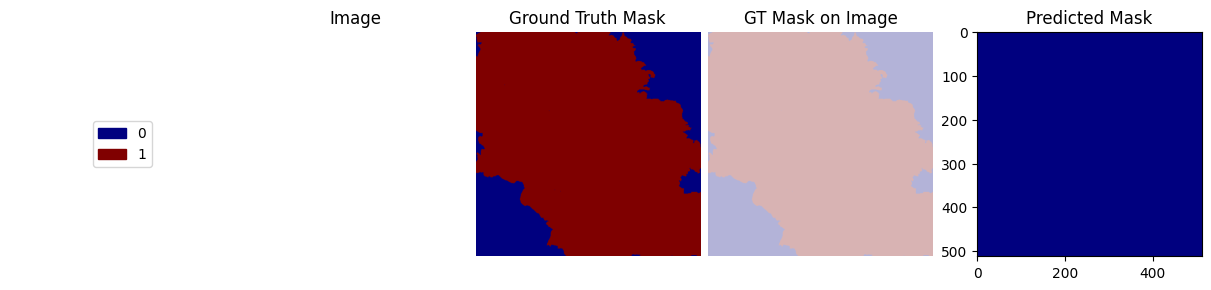

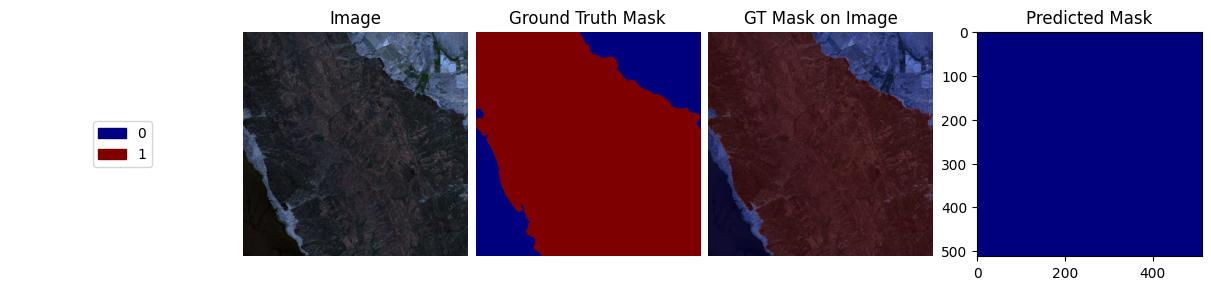

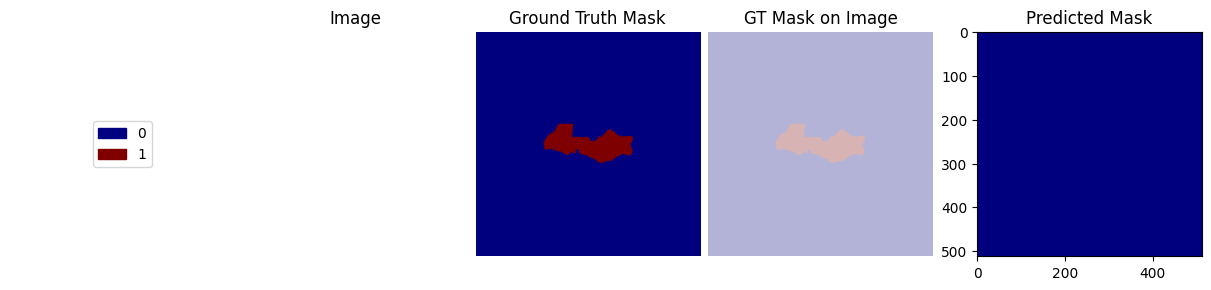

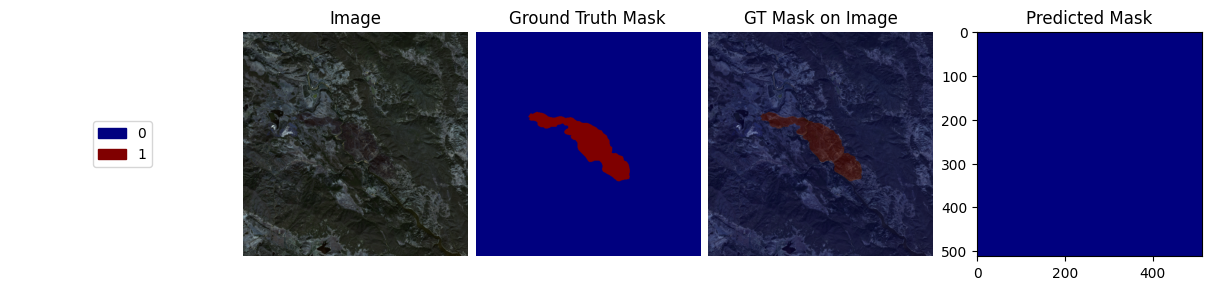

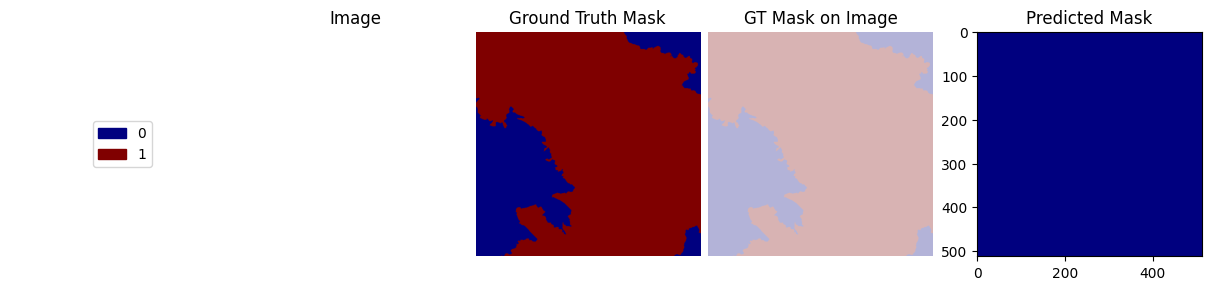

In [ ]:
# now we can use the model for predictions and plotting!
# Modified to use the user's specific checkpoint path
custom_ckpt_path = "/content/drive/MyDrive/burn_intensity_project/best-epoch=00.ckpt"

model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    custom_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(model.device)
    masks = batch["mask"].numpy()

    outputs = model(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {key: batch[key][i] for key in batch}
    sample["prediction"] = preds[i]
    test_dataset.plot(sample)

## Results Summary

The Random Forest baseline achieved accuracy 0.956, mean IoU 0.757, burned-class IoU 0.567, and MSE 0.044.

The available Prithvi-EO-2.0 checkpoint achieved accuracy 0.896 and mean IoU 0.448, but its burned-class IoU was 0.0. This means the checkpoint mostly predicted the majority unburned class.

Because the Prithvi model could not be fully fine-tuned due to limited RAM and compute resources, this comparison should be interpreted as a comparison against the available checkpoint rather than the full capability of Prithvi-EO-2.0.